In [1]:
import sys
sys.path.append('/home/gluo/mitax')

import os
os.environ['CUDA_DEVICE_ORDER']='PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES']='2'

from mitax.sampler import AncestralSampler, progressive_sampling
from mitax.misc import utils

import jax.numpy as jnp
import jax
import numpy as np

savecfl  = lambda p, a: utils.writecfl(p, utils.float2cplx(a)) if a.shape[-1] == 2 else utils.writecfl(p, a)
evalpath = lambda pr, ch: os.path.join(pr, ch)


In [2]:
logdir='/home/gluo/mitax/examples/log/20240110-201054'
config = utils.load_config(logdir+'/config.yaml')

sampler = AncestralSampler(net_name      = config['net_name'],
                           net_hparams   = config['net_hparams'],
                           dm_name       = config['loss_name'],
                           dm_hparams    = config['loss_params'],
                           target_snr    = 0.2,
                           init_input    = {'x': jnp.ones((1, 256, 256, 2), dtype=jnp.float32), 't': jnp.ones((1), dtype=jnp.float32)},
                           path          = logdir+'/mitax.model.unet.ncsnpp_919')

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from functools import partial

def subplot(ax, img, title, cmap, interpolation, vmin, vmax):
    ax.imshow(img, cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')

plot_params = {'cmap': 'gray', 'interpolation': 'none', 'vmin': 0}
axplot      = partial(subplot, **plot_params)
grid_x=3
grid_y=3

def plot_grid(image_n):
    
    images=np.abs(utils.float2cplx(image_n))
    fig, axss = plt.subplots(grid_x, grid_y, figsize=(10, 10), gridspec_kw={'width_ratios': [1  for _ in range(grid_x)]})
    for i in range(grid_x):
        for j in range(grid_y):
            if i==0:
                strs='x_%d'%j
            else:
                strs=''
            axplot(axss[i,j], images[i*grid_y+j], title=strs, vmax=np.max(images[i*grid_y+j]))
    plt.tight_layout(pad=0.)

  0%|          | 0/10 [00:00<?, ?it/s]

(9, 1, 1, 1)


  0%|          | 0/30 [00:00<?, ?it/s]

(9, 1, 1, 1)


100%|██████████| 30/30 [00:13<00:00,  2.17it/s]


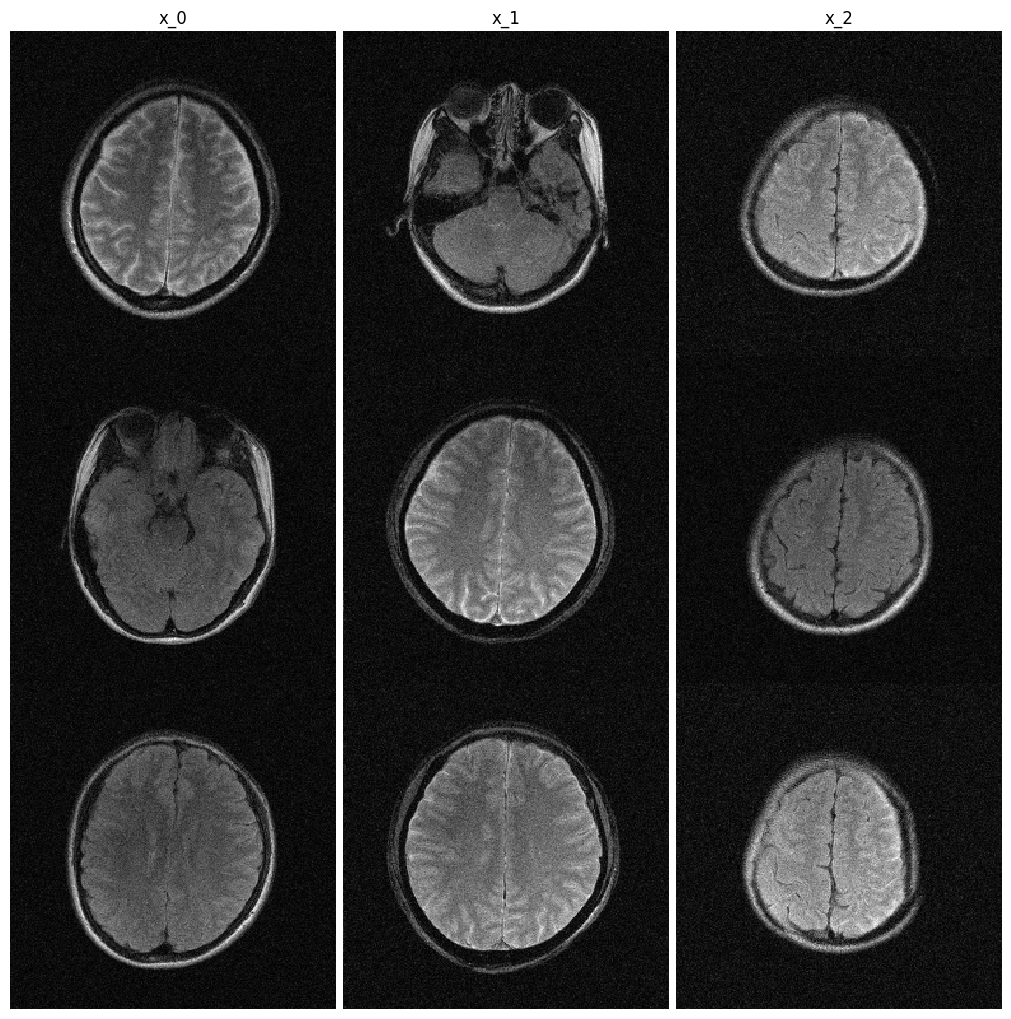

In [4]:
sampler.dm.continuous = False
sampler.dm.sigma_min = 0.001
input_shape=(9, 256, 256, 2)
image = progressive_sampling(sampler, 
                   Ns = [10, 30],
                   sigmaxs = [10, 1.5],
                   rhos = [6, 8],
                   x_init = jax.random.normal(jax.random.PRNGKey(4), input_shape)*config['loss_params']['sigma_max'],
                   inner_steps=1)
plot_grid(image)


  0%|          | 0/5 [00:00<?, ?it/s]

(9, 1, 1, 1)


  0%|          | 0/45 [00:00<?, ?it/s]

(9, 1, 1, 1)


100%|██████████| 45/45 [00:16<00:00,  2.69it/s]


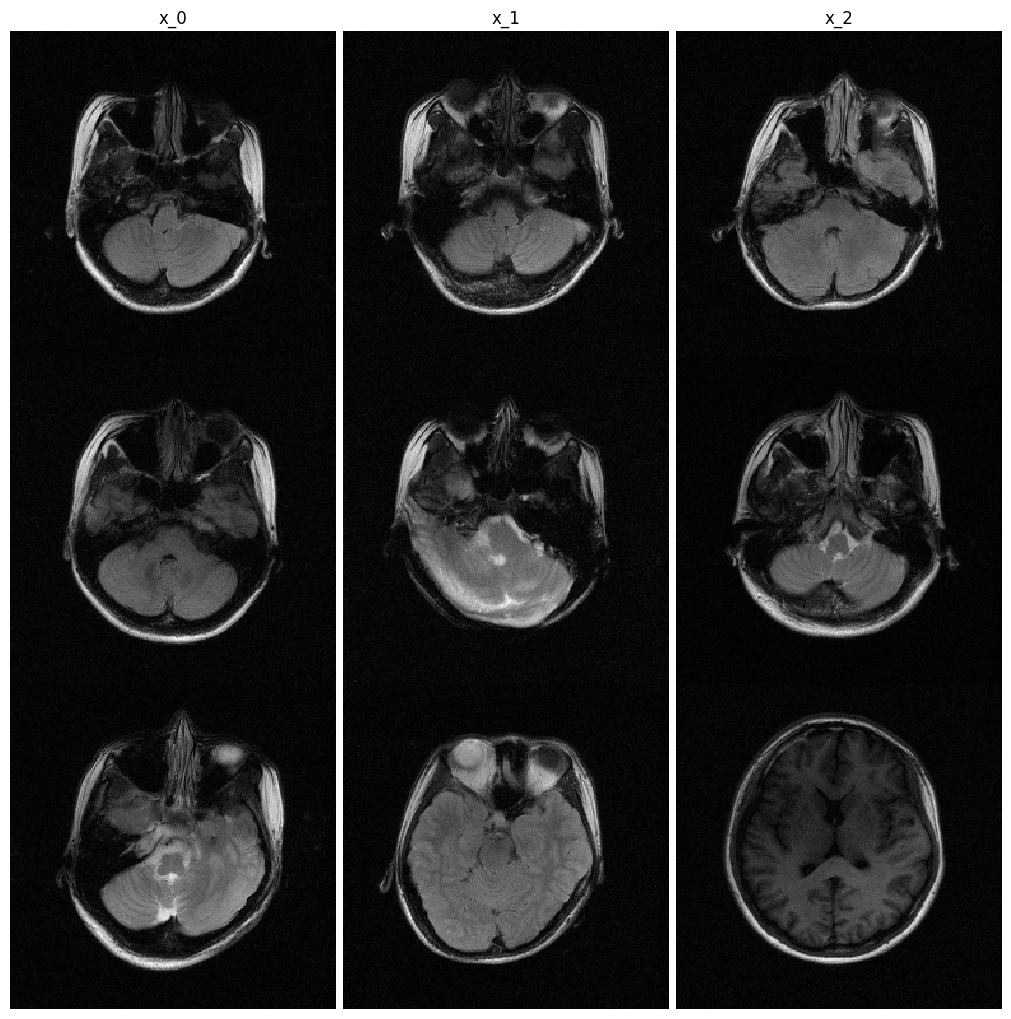

In [5]:
sampler.dm.continuous = True
sampler.dm.sigma_min = 0.001
input_shape=(9, 256, 256, 2)
image = progressive_sampling(sampler, 
                   Ns = [5, 45],
                   sigmaxs = [11, 3],
                   rhos = [7, 5],
                   x_init = jax.random.normal(jax.random.PRNGKey(4), input_shape)*config['loss_params']['sigma_max'],
                   inner_steps=1)
plot_grid(image)

  0%|          | 0/100 [00:00<?, ?it/s]

(9, 1, 1, 1)


100%|██████████| 100/100 [00:26<00:00,  3.78it/s]


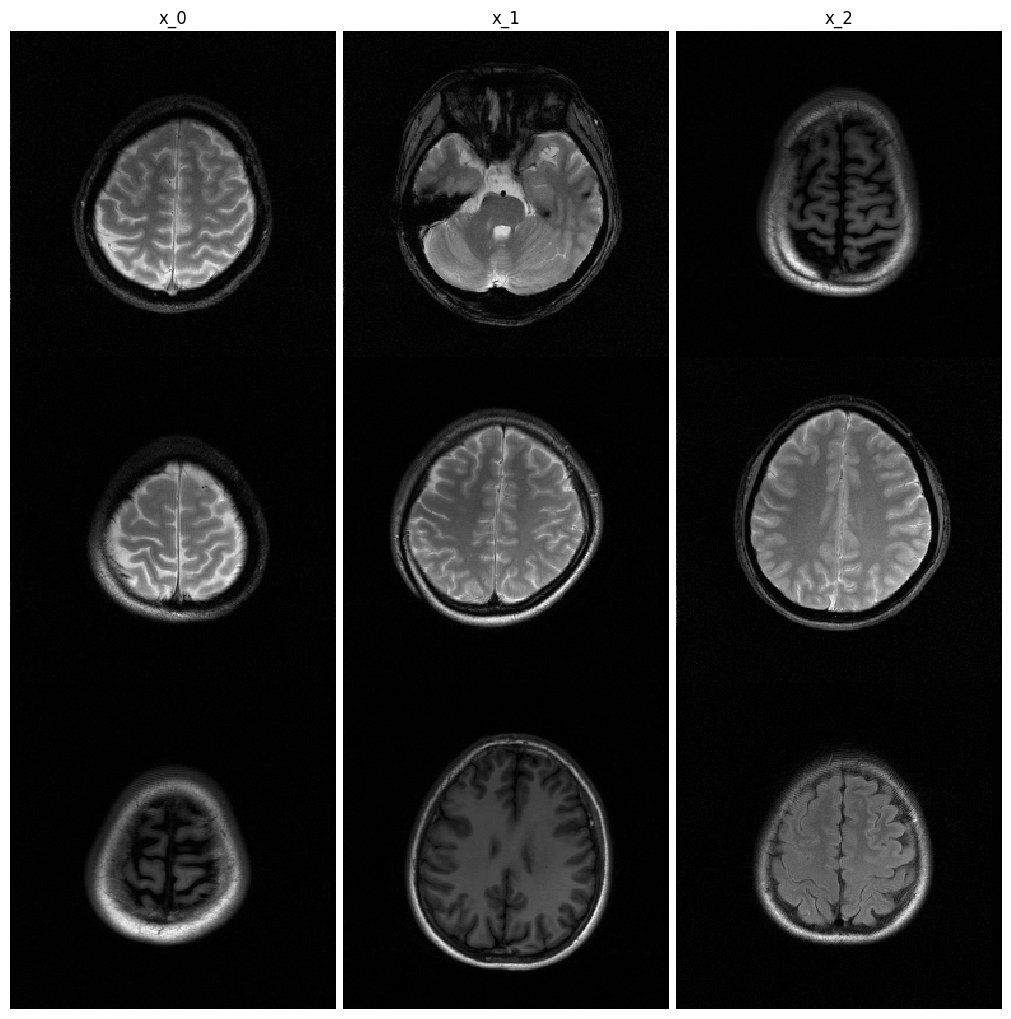

In [6]:
sampler.dm.continuous = True
sampler.dm.N = 100
sampler.dm.sigma_max = 10.
sampler.dm.sigma_min = 0.001
sampler.dm.rho = 6
sampler.create_functions()

_, image1 = sampler(jax.random.normal(jax.random.PRNGKey(4), input_shape)*sampler.dm.sigma_max, inner_steps=1)
plot_grid(image1)


  0%|          | 0/100 [00:00<?, ?it/s]

(9, 1, 1, 1)


100%|██████████| 100/100 [00:25<00:00,  3.86it/s]


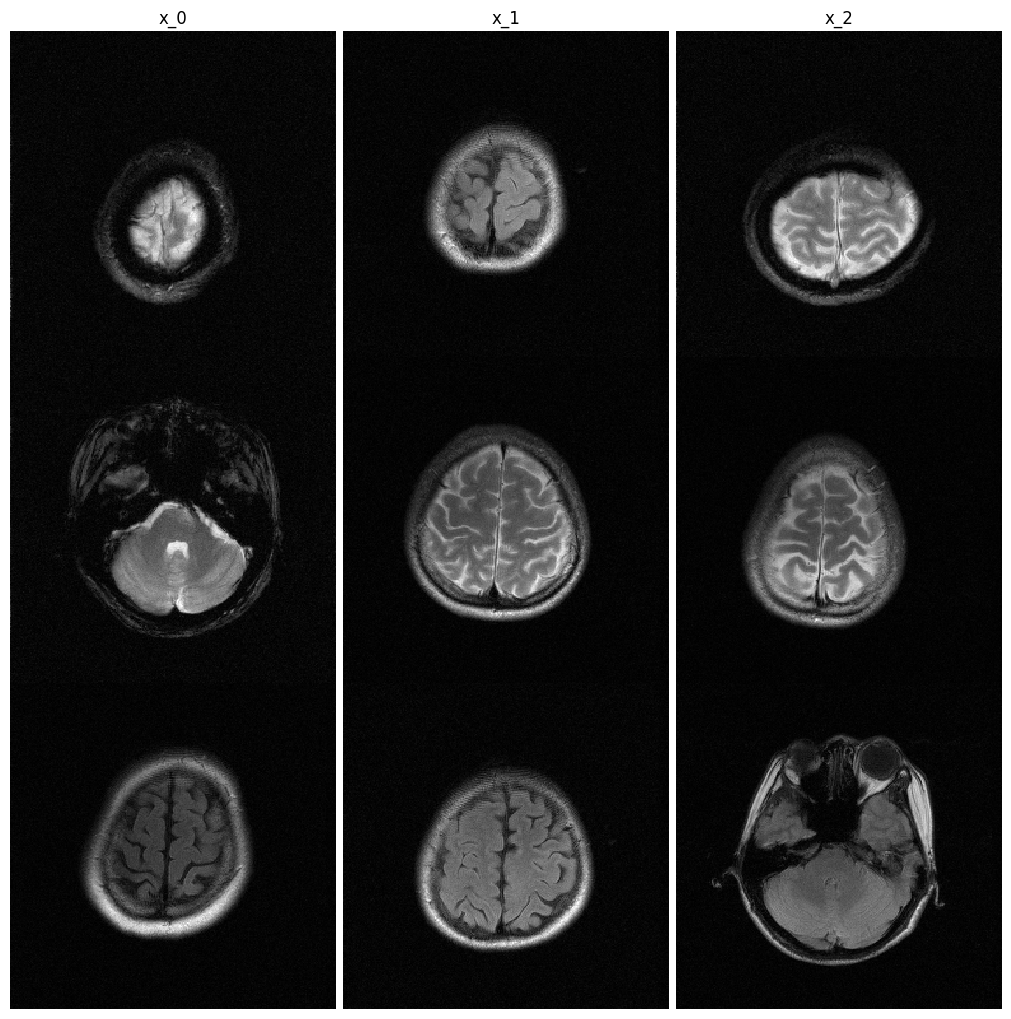

In [7]:
sampler.dm.continuous = False
sampler.create_functions()
_, image2 = sampler(jax.random.normal(jax.random.PRNGKey(4), input_shape)*sampler.dm.sigma_max, inner_steps=1)
plot_grid(image2)